In [39]:
import pandas as pd
from pandasql import sqldf
from prophet import Prophet

In [40]:
df=pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [41]:
print(df.shape)
print(df.columns.tolist())

(9800, 18)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [42]:
# Keep only relevant columns
df = df[["Order ID", "Order Date", "Ship Mode", "Segment",
         "Region", "Category", "Sub-Category", "Sales"]]

df.head()

,Order ID,Order Date,Ship Mode,Segment,Region,Category,Sub-Category,Sales
0,CA-2017-152156,08/11/2017,Second Class,Consumer,South,Furniture,Bookcases,261.9600
1,CA-2017-152156,08/11/2017,Second Class,Consumer,South,Furniture,Chairs,731.9400
2,CA-2017-138688,12/06/2017,Second Class,Corporate,West,Office Supplies,Labels,14.6200
3,US-2016-108966,11/10/2016,Standard Class,Consumer,South,Furniture,Tables,957.5775
4,US-2016-108966,11/10/2016,Standard Class,Consumer,South,Office Supplies,Storage,22.3680


In [43]:
# Convert Order Date to datetime (DD/MM/YYYY format)
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

# Extract year and month
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

df.head()

,Order ID,Order Date,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Year,Month
0,CA-2017-152156,2017-11-08,Second Class,Consumer,South,Furniture,Bookcases,261.9600,2017,11
1,CA-2017-152156,2017-11-08,Second Class,Consumer,South,Furniture,Chairs,731.9400,2017,11
2,CA-2017-138688,2017-06-12,Second Class,Corporate,West,Office Supplies,Labels,14.6200,2017,6
3,US-2016-108966,2016-10-11,Standard Class,Consumer,South,Furniture,Tables,957.5775,2016,10
4,US-2016-108966,2016-10-11,Standard Class,Consumer,South,Office Supplies,Storage,22.3680,2016,10


In [44]:
!pip install pandasql

In [45]:
pysql = lambda q: sqldf(q, globals())

In [46]:
# Total sales by region
result = pysql("""
    SELECT Region, ROUND(SUM(Sales), 2) as Total_Sales
    FROM df
    GROUP BY Region
    ORDER BY Total_Sales DESC
""")
print(result)

    Region  Total_Sales
0     West    710219.68
1     East    669518.73
2  Central    492646.91
3    South    389151.46


In [47]:
# Total sales by category
result2 = pysql("""
    SELECT Category, ROUND(SUM(Sales), 2) as Total_Sales
    FROM df
    GROUP BY Category
    ORDER BY Total_Sales DESC
""")
print(result2)

          Category  Total_Sales
0       Technology    827455.87
1        Furniture    728658.58
2  Office Supplies    705422.33


In [48]:
# Total sales by segment
result3 = pysql("""
    SELECT Segment, ROUND(SUM(Sales), 2) as Total_Sales
    FROM df
    GROUP BY Segment
    ORDER BY Total_Sales DESC
""")
print("Sales by Segment:")
print(result3)

Sales by Segment:
       Segment  Total_Sales
0     Consumer   1148060.53
1    Corporate    688494.07
2  Home Office    424982.18


In [49]:
# Total sales by year
result4 = pysql("""
    SELECT Year, ROUND(SUM(Sales), 2) as Total_Sales
    FROM df
    GROUP BY Year
    ORDER BY Year
""")
print("\nSales by Year:")
print(result4)


Sales by Year:
   Year  Total_Sales
0  2015    479856.21
1  2016    459436.01
2  2017    600192.55
3  2018    722052.02


In [50]:
# Top 10 sub-categories
result5 = pysql("""
    SELECT "Sub-Category", ROUND(SUM(Sales), 2) as Total_Sales
    FROM df
    GROUP BY "Sub-Category"
    ORDER BY Total_Sales DESC
    LIMIT 10
""")
print("\nTop 10 Sub-Categories:")
print(result5)


Top 10 Sub-Categories:
  Sub-Category  Total_Sales
0       Phones    327782.45
1       Chairs    322822.73
2      Storage    219343.39
3       Tables    202810.63
4      Binders    200028.79
5     Machines    189238.63
6  Accessories    164186.70
7      Copiers    146248.09
8    Bookcases    113813.20
9   Appliances    104618.40


In [51]:
# Investigate 2016 sales drop by category
result6 = pysql("""
    SELECT Year, Category, ROUND(SUM(Sales), 2) as Total_Sales
    FROM df
    WHERE Year IN (2015, 2016, 2017)
    GROUP BY Year, Category
    ORDER BY Year, Total_Sales DESC
""")
print(result6)

   Year         Category  Total_Sales
0  2015       Technology    173865.51
1  2015        Furniture    156477.88
2  2015  Office Supplies    149512.82
3  2016        Furniture    164053.87
4  2016       Technology    162257.73
5  2016  Office Supplies    133124.41
6  2017       Technology    221961.94
7  2017        Furniture    195813.04
8  2017  Office Supplies    182417.57


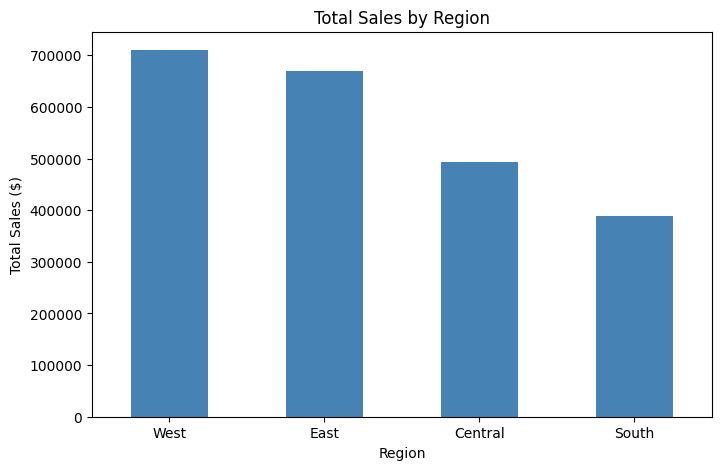

In [53]:
# 1. Sales by Region
result.plot(kind="bar", x="Region", y="Total_Sales",
            color="steelblue", legend=False, figsize=(8, 5))
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()


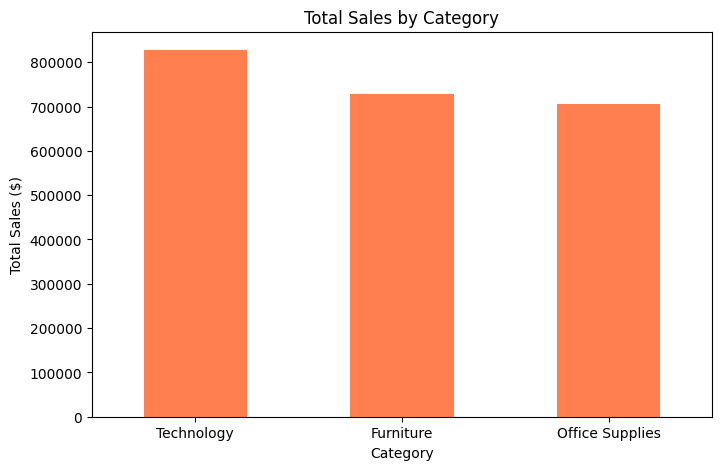

In [54]:
# 2. Sales by Category
result2.plot(kind="bar", x="Category", y="Total_Sales",
             color="coral", legend=False, figsize=(8, 5))
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

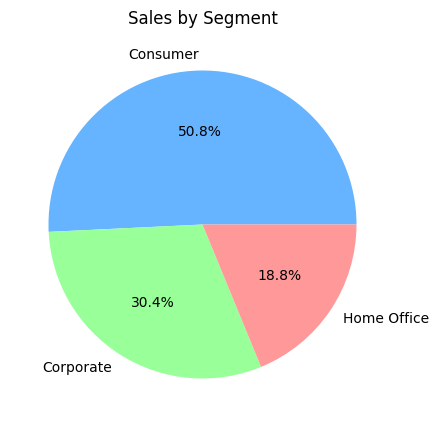

In [55]:
# 3. Sales by Segment
plt.figure(figsize=(8, 5))
plt.pie(result3["Total_Sales"], labels=result3["Segment"],
        autopct='%1.1f%%', colors=["#66b3ff","#99ff99","#ff9999"])
plt.title("Sales by Segment")
plt.show()

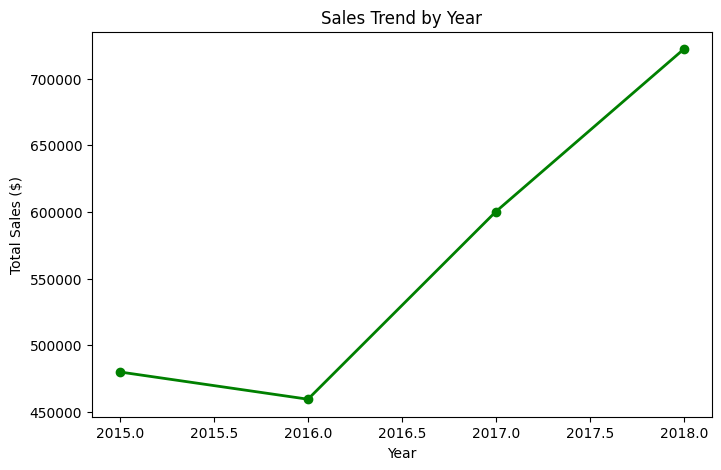

In [56]:
# 4. Sales Trend by Year
plt.figure(figsize=(8, 5))
plt.plot(result4["Year"], result4["Total_Sales"],
         marker='o', color="green", linewidth=2)
plt.title("Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.show()

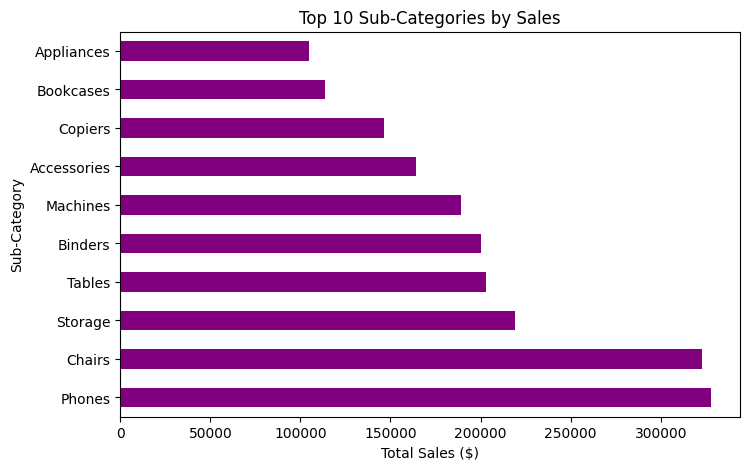

In [58]:
# 5. Top 10 Sub-Categories
result5.plot(kind="barh", x="Sub-Category", y="Total_Sales",
             color="purple", legend=False, figsize=(8, 5))
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales ($)")
plt.show()

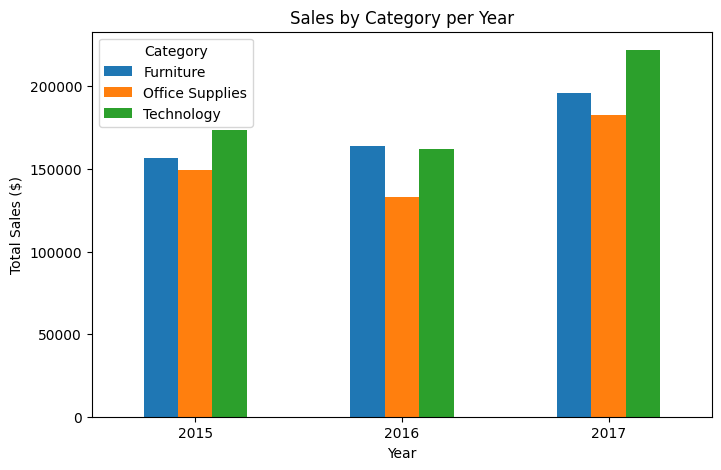

In [59]:
# 6. Sales by Category per Year
result6_pivot = result6.pivot(
    index="Year", columns="Category", values="Total_Sales"
)
result6_pivot.plot(kind="bar", figsize=(8, 5))
plt.title("Sales by Category per Year")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.show()

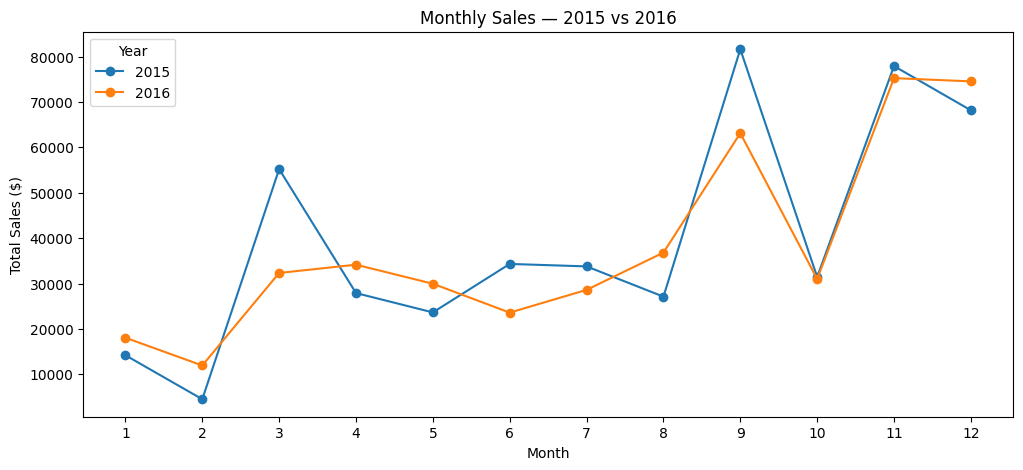

In [60]:
# Monthly sales for 2016 vs 2015
result7 = pysql("""
    SELECT Year, Month, ROUND(SUM(Sales), 2) as Total_Sales
    FROM df
    WHERE Year IN (2015, 2016)
    GROUP BY Year, Month
    ORDER BY Year, Month
""")

# Visualize
result7_pivot = result7.pivot(index="Month", columns="Year", values="Total_Sales")
result7_pivot.plot(kind="line", figsize=(12, 5), marker='o')
plt.title("Monthly Sales — 2015 vs 2016")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(range(1, 13))
plt.show()

In [61]:
!pip install prophet

In [62]:
# Prepare data for Prophet — requires 'ds' (date) and 'y' (target) columns
df_prophet = pysql("""
    SELECT "Order Date" as ds, SUM(Sales) as y
    FROM df
    GROUP BY "Order Date"
    ORDER BY "Order Date"
""")

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])
df_prophet.head()

,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


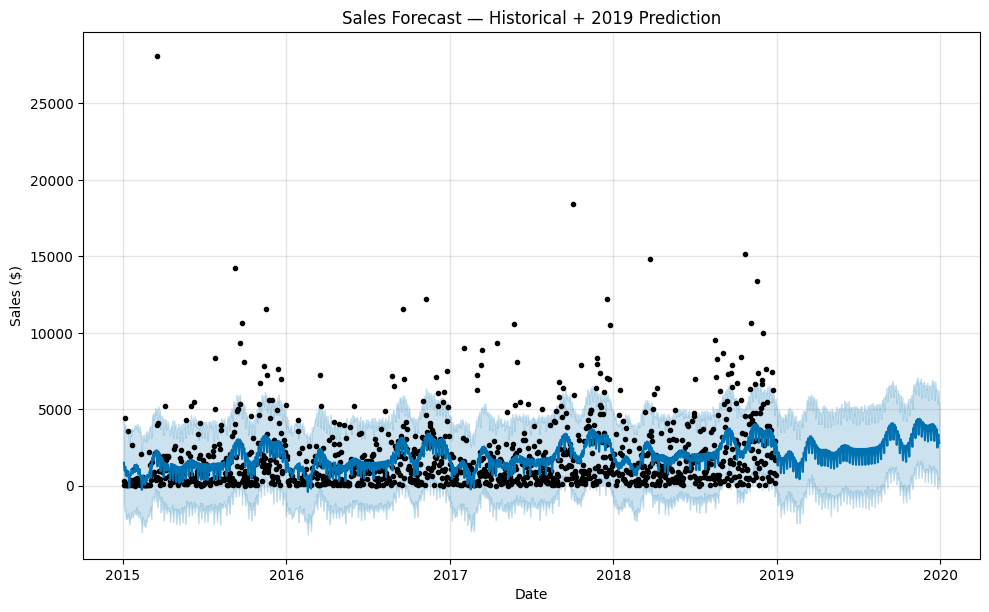

In [63]:
# Build and train Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(df_prophet)

# Create future dataframe for 2019 prediction (365 days)
future = model.make_future_dataframe(periods=365)

# Generate predictions
forecast = model.predict(future)

# Visualize forecast
fig = model.plot(forecast)
plt.title("Sales Forecast — Historical + 2019 Prediction")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.show()

In [64]:
# Aggregate by month for better predictions
df_monthly = pysql("""
    SELECT
        Year || '-' || printf('%02d', Month) || '-01' as ds,
        ROUND(SUM(Sales), 2) as y
    FROM df
    GROUP BY Year, Month
    ORDER BY Year, Month
""")

df_monthly["ds"] = pd.to_datetime(df_monthly["ds"])
df_monthly.head()

,ds,y
0,2015-01-01,14205.71
1,2015-02-01,4519.89
2,2015-03-01,55205.80
3,2015-04-01,27906.86
4,2015-05-01,23644.30


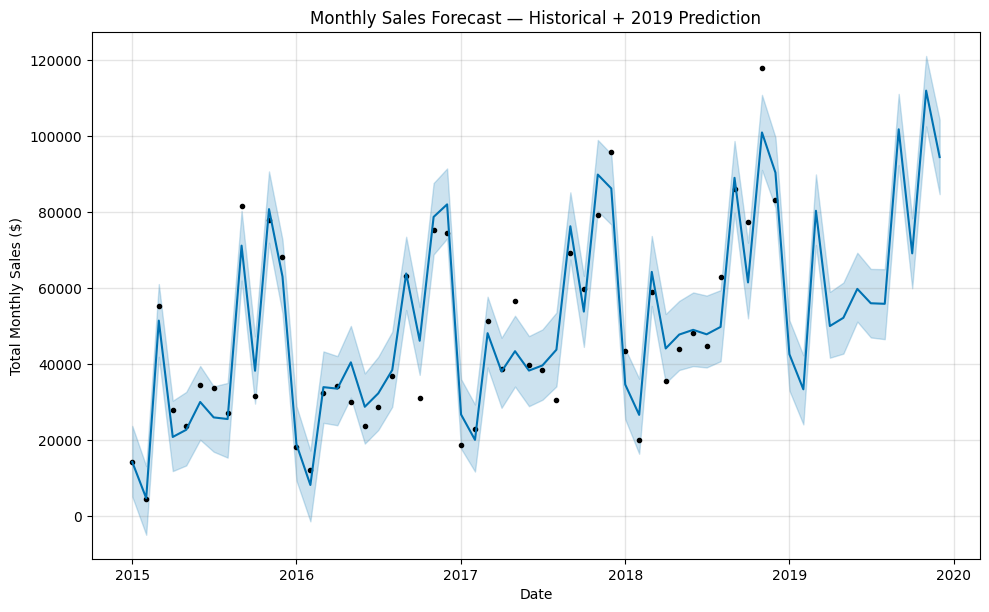

In [66]:
# Build and train Prophet model on monthly data
model_monthly = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_monthly.fit(df_monthly)

# Create future dataframe — 12 months ahead (2019)
future_monthly = model_monthly.make_future_dataframe(
    periods=12,
    freq='MS'
)

# Generate predictions
forecast_monthly = model_monthly.predict(future_monthly)

# Visualize forecast
fig = model_monthly.plot(forecast_monthly)
plt.title("Monthly Sales Forecast — Historical + 2019 Prediction")
plt.xlabel("Date")
plt.ylabel("Total Monthly Sales ($)")
plt.show()

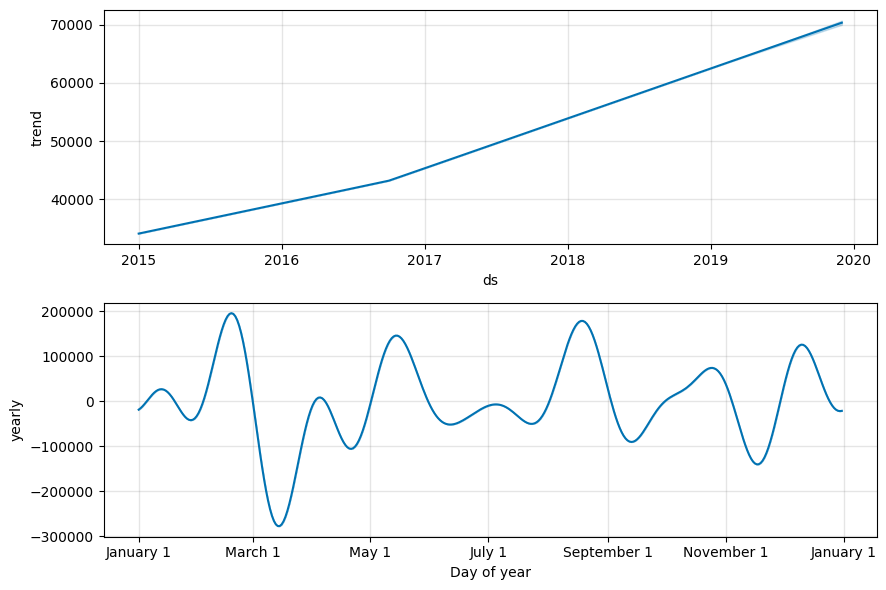

In [67]:
# Plot forecast components
fig2 = model_monthly.plot_components(forecast_monthly)
plt.show()

In [68]:
# Show 2019 monthly predictions
forecast_2019 = forecast_monthly[
    forecast_monthly["ds"].dt.year == 2019
][["ds", "yhat", "yhat_lower", "yhat_upper"]].round(2)

forecast_2019.columns = ["Month", "Predicted Sales", "Lower Bound", "Upper Bound"]
print(forecast_2019.to_string(index=False))

     Month  Predicted Sales  Lower Bound  Upper Bound
2019-01-01         42548.01     32984.22     51456.13
2019-02-01         33309.98     24070.06     42274.34
2019-03-01         80304.52     71307.81     89866.44
2019-04-01         49968.36     41622.46     58950.18
2019-05-01         52137.27     42702.26     61408.78
2019-06-01         59742.12     51119.73     69252.90
2019-07-01         55962.50     46958.81     64996.65
2019-08-01         55817.66     46504.15     64930.81
2019-09-01        101744.63     92297.54    111071.93
2019-10-01         69091.74     59909.36     78341.39
2019-11-01        111918.79    102515.76    121056.44
2019-12-01         94436.03     84668.86    104304.71


In [69]:
# Total predicted sales for 2019
total_2019 = forecast_2019["Predicted Sales"].sum()
print(f"Total predicted sales for 2019: ${total_2019:,.2f}")

Total predicted sales for 2019: $806,981.61


# Superstore Sales Analysis — Complete Project Summary

## Project Overview
End-to-end sales analysis using SQL, Python, and Prophet
time series forecasting on 9,800 transactions (2015-2018).

## Dataset
- 9,800 orders | 4 years (2015-2018) | United States
- 3 categories | 4 regions | 3 customer segments

## Part 1 — SQL Analysis

### Sales by Region
| Region | Total Sales |
|---|---|
| West | $710,219 🥇 |
| East | $669,518 |
| Central | $492,646 |
| South | $389,151 ⚠️ |

### Sales by Category
| Category | Total Sales |
|---|---|
| Technology | $827,455 🥇 |
| Furniture | $728,658 |
| Office Supplies | $705,422 |

### Sales by Segment
| Segment | Total Sales |
|---|---|
| Consumer | $1,148,060 (46%) 🥇 |
| Corporate | $688,494 (28%) |
| Home Office | $424,982 (17%) |

### Top 3 Sub-Categories
1. Phones — $327,782
2. Chairs — $322,822
3. Storage — $219,343

## Part 2 — Sales Trend Analysis

| Year | Total Sales | Growth |
|---|---|---|
| 2015 | $479,856 | — |
| 2016 | $459,436 | ↘️ -4.2% |
| 2017 | $600,192 | ↗️ +30.6% |
| 2018 | $722,052 | ↗️ +20.3% |

### 2016 Drop Investigation
- Root cause: exceptional March 2015 peak not reproduced
- Secondary cause: sharp drop in October 2016
- Technology and Office Supplies most affected

## Part 3 — Prophet Time Series Forecasting

### 2019 Monthly Predictions
| Month | Predicted Sales |
|---|---|
| February | $33,309 📉 Lowest |
| March | $80,304 📈 First peak |
| September | $101,744 📈 Second peak |
| November | $111,918 🌟 Highest |
| **Total 2019** | **$806,981** |

### Key Seasonal Pattern
- Q1: Strong start then drop in February
- Q3: Recovery in September
- Q4: Best quarter of the year — November peak

## Business Recommendations

1. **South region** — invest in marketing campaigns (+82% gap vs West)
2. **February & December** — launch promotions to offset seasonal lows
3. **March & September** — maximize inventory before peaks
4. **Home Office segment** — growth opportunity, currently underperforming
5. **Technology category** — maintain leadership with new products
6. **October anomaly** — investigate supply chain disruptions

## Tech Stack
Python | Pandas | SQL (pandasql) | Matplotlib | Prophet

In [70]:
# Export cleaned data for Power BI
df.to_csv("superstore_clean.csv", index=False)

# Export 2019 predictions
forecast_2019.to_csv("forecast_2019.csv", index=False)

print("Files exported successfully!")

Files exported successfully!
